<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/PraticaQuest%C3%A3o7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questão 3 (H de fase mínima):
  M=    2: SNR =    5.95 dB
  M=    5: SNR =    9.88 dB
  M=   10: SNR =   14.18 dB
  M=   20: SNR =   18.97 dB
  M=   50: SNR =   36.99 dB
  M=  100: SNR =   66.83 dB
  M=  150: SNR =   96.67 dB
  M=  200: SNR =  126.51 dB
  M=  300: SNR =  186.19 dB
  M=  500: SNR =  305.27 dB
  M= 1000: SNR =  317.28 dB
  M= 2000: SNR =  315.29 dB

Questão 6, a=0.7, L=1:
  M=    2: SNR =    4.76 dB
  M=    5: SNR =    4.76 dB
  M=   10: SNR =    4.76 dB
  M=   20: SNR =    4.76 dB
  M=   50: SNR =    4.77 dB
  M=  100: SNR =    4.77 dB
  M=  150: SNR =    4.77 dB
  M=  200: SNR =    4.77 dB
  M=  300: SNR =    4.77 dB
  M=  500: SNR =    4.78 dB
  M= 1000: SNR =    4.79 dB
  M= 2000: SNR =    4.83 dB

Questão 6, a=0.7, L=4:
  M=    2: SNR =   11.85 dB
  M=    5: SNR =   11.85 dB
  M=   10: SNR =   11.85 dB
  M=   20: SNR =   11.85 dB
  M=   50: SNR =   11.85 dB
  M=  100: SNR =   11.86 dB
  M=  150: SNR =   11.86 dB
  M=  200: SNR =   11.86 dB
  M=  300: SNR =   11.86 d

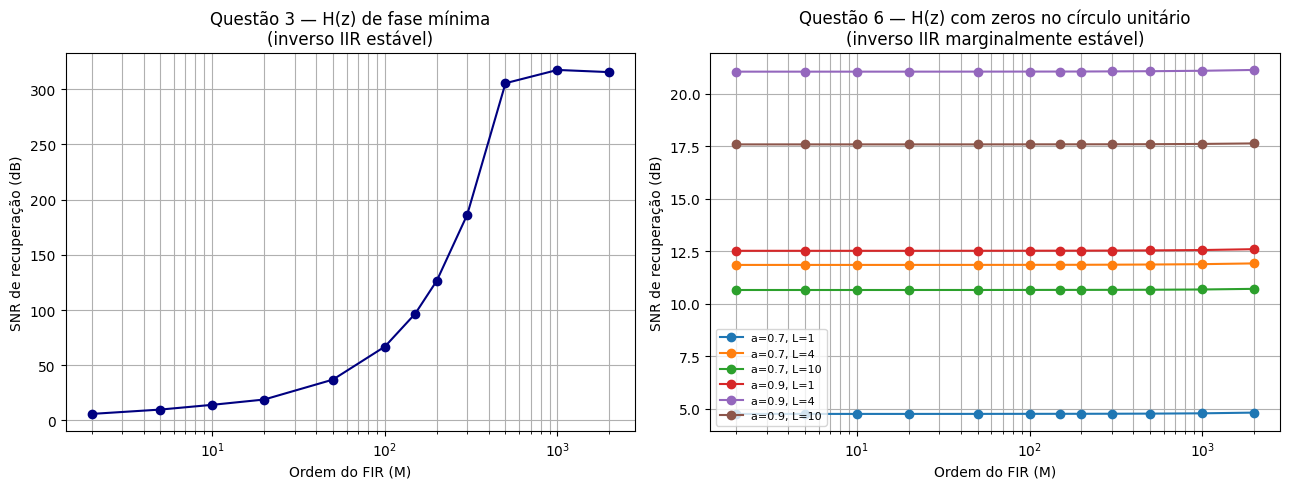

/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


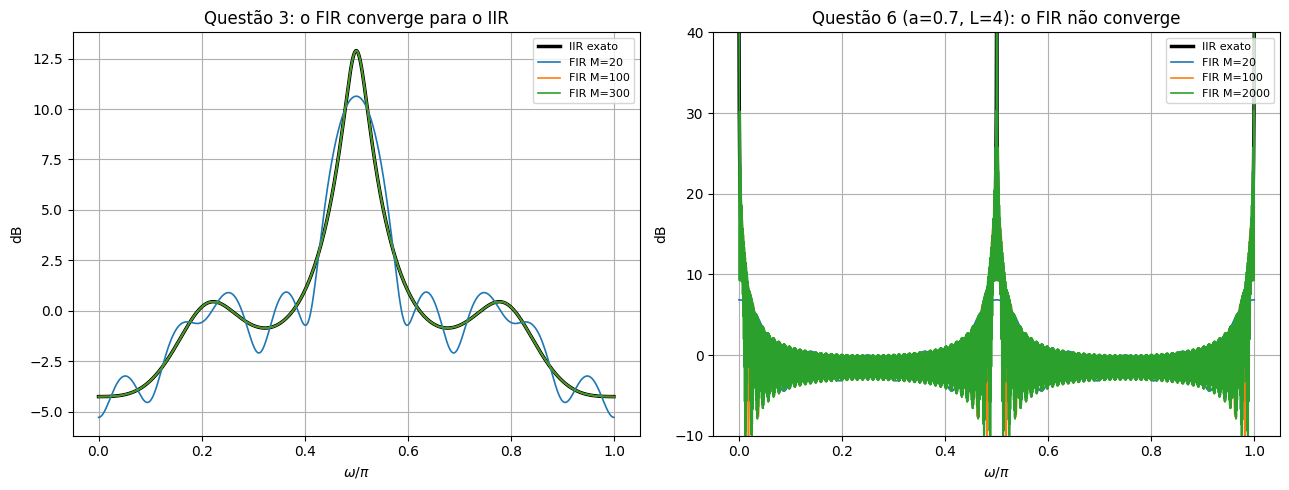

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import urllib.request
from scipy.io import wavfile

# ================== Carrega o áudio ==================
url = "https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_03/Audios_Usados/handel.wav"
urllib.request.urlretrieve(url, "handel.wav")
fs, x_int = wavfile.read("handel.wav")
x = x_int.astype(np.float64) / np.iinfo(x_int.dtype).max
Ex = np.sum(x**2)

# ================== Método: FIR por truncamento da resposta ao impulso ==================
def fir_por_truncamento(b_inv, a_inv, M):
    """Constrói um FIR de M coeficientes truncando a resposta ao impulso do IIR (b_inv, a_inv)."""
    impulso = np.zeros(M); impulso[0] = 1.0
    return signal.lfilter(b_inv, a_inv, impulso)

# --- Sistema da Questão 1/3: H(z) FIR de fase mínima ---
b1 = np.zeros(13)
b1[0]=1; b1[2]=0.49; b1[6]=0.2401; b1[8]=-0.0576; b1[10]=-0.0282; b1[12]=-0.0138
a1 = np.array([1.0])
y1 = signal.lfilter(b1, a1, x)
b_inv1, a_inv1 = np.array([1.0]), b1.copy()   # G(z) = 1/H(z), o inverso IIR estável da Q3

# --- Sistemas da Questão 4/6: H(z) = (1-z^-L)/(1-a z^-L) ---
def coeficientes(a, L):
    b = np.zeros(L + 1); b[0] = 1; b[L] = -1
    a_coef = np.zeros(L + 1); a_coef[0] = 1; a_coef[L] = -a
    return b, a_coef

def inverso_exato(a, L):
    b, a_coef = coeficientes(a, L)
    return a_coef.copy(), b.copy()

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

# ================== SNR de recuperação em função da ordem do FIR ==================
ordens = [2, 5, 10, 20, 50, 100, 150, 200, 300, 500, 1000, 2000]

# --- Q3 ---
SNR_q3 = []
for M in ordens:
    h_fir = fir_por_truncamento(b_inv1, a_inv1, M)
    x_rec = signal.lfilter(h_fir, [1.0], y1)
    SNR_q3.append(10 * np.log10(Ex / np.sum((x - x_rec) ** 2)))

print("Questão 3 (H de fase mínima):")
for M, snr in zip(ordens, SNR_q3):
    print(f"  M={M:5d}: SNR = {snr:7.2f} dB")

# --- Q6 ---
SNR_q6 = {}
for a in valores_a:
    for L in valores_L:
        b, a_coef = coeficientes(a, L)
        y = signal.lfilter(b, a_coef, x)
        b_inv, a_inv = inverso_exato(a, L)

        snrs = []
        for M in ordens:
            h_fir = fir_por_truncamento(b_inv, a_inv, M)
            x_rec = signal.lfilter(h_fir, [1.0], y)
            snrs.append(10 * np.log10(Ex / np.sum((x - x_rec) ** 2)))
        SNR_q6[(a, L)] = snrs

        print(f"\nQuestão 6, a={a}, L={L}:")
        for M, snr in zip(ordens, snrs):
            print(f"  M={M:5d}: SNR = {snr:7.2f} dB")

# ================== Gráfico: SNR vs. ordem do FIR ==================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.semilogx(ordens, SNR_q3, 'o-', color="navy")
ax1.set_title("Questão 3 — H(z) de fase mínima\n(inverso IIR estável)")
ax1.set_xlabel("Ordem do FIR (M)")
ax1.set_ylabel("SNR de recuperação (dB)")
ax1.grid(True, which="both")

for (a, L), snrs in SNR_q6.items():
    ax2.semilogx(ordens, snrs, 'o-', label=f"a={a}, L={L}")
ax2.set_title("Questão 6 — H(z) com zeros no círculo unitário\n(inverso IIR marginalmente estável)")
ax2.set_xlabel("Ordem do FIR (M)")
ax2.set_ylabel("SNR de recuperação (dB)")
ax2.legend(fontsize=8)
ax2.grid(True, which="both")

plt.tight_layout()
plt.show()

# ================== Resposta em frequência: FIR truncado vs. IIR original ==================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Q3: convergência clara ao aumentar M ---
w, G_iir = signal.freqz(b_inv1, a_inv1, worN=4096)
axes[0].plot(w/np.pi, 20*np.log10(np.abs(G_iir)+1e-12), 'k', linewidth=2.5, label="IIR exato")
for M in [20, 100, 300]:
    h_fir = fir_por_truncamento(b_inv1, a_inv1, M)
    w, G_fir = signal.freqz(h_fir, [1.0], worN=4096)
    axes[0].plot(w/np.pi, 20*np.log10(np.abs(G_fir)+1e-12), linewidth=1.2, label=f"FIR M={M}")
axes[0].set_title("Questão 3: o FIR converge para o IIR")
axes[0].set_xlabel(r"$\omega/\pi$"); axes[0].set_ylabel("dB"); axes[0].legend(fontsize=8); axes[0].grid(True)

# --- Q6 (exemplo a=0.7, L=4): sem convergência visível ---
a_ex, L_ex = 0.7, 4
b_inv_ex, a_inv_ex = inverso_exato(a_ex, L_ex)
w, G_iir = signal.freqz(b_inv_ex, a_inv_ex, worN=4096)
axes[1].plot(w/np.pi, 20*np.log10(np.abs(G_iir)+1e-12), 'k', linewidth=2.5, label="IIR exato")
for M in [20, 100, 2000]:
    h_fir = fir_por_truncamento(b_inv_ex, a_inv_ex, M)
    w, G_fir = signal.freqz(h_fir, [1.0], worN=4096)
    axes[1].plot(w/np.pi, 20*np.log10(np.abs(G_fir)+1e-12), linewidth=1.2, label=f"FIR M={M}")
axes[1].set_ylim(-10, 40)
axes[1].set_title(f"Questão 6 (a={a_ex}, L={L_ex}): o FIR não converge")
axes[1].set_xlabel(r"$\omega/\pi$"); axes[1].set_ylabel("dB"); axes[1].legend(fontsize=8); axes[1].grid(True)

plt.tight_layout()
plt.show()

Um FIR construído por truncamento da resposta ao impulso do IIR só melhora com a ordem na medida em que essa resposta ao impulso decai. Na Questão 3, o inverso é estável (maior polo em |z|=0,9336), então a resposta ao impulso decai geometricamente como 0,9336ⁿ, e cada tap adicional melhora a SNR em aproximadamente 20·log₁₀(1/0,9336) ≈ 0,6 dB — exatamente a inclinação observada entre M=100 e M=200 (ganho de ~60 dB em 100 taps). Com M≈500-1000 a SNR já ultrapassa 300 dB, essencialmente igualando o inverso IIR ideal: mais ordem = melhor recuperação, de forma monotônica e previsível.

Já na Questão 6, o inverso tem polos exatamente sobre o círculo unitário, então sua resposta ao impulso não decai (fica oscilando/constante indefinidamente). Por isso a SNR satura já nas primeiras amostras (M≈5-10) e praticamente não melhora mais mesmo aumentando a ordem em três ordens de grandeza (de M=5 a M=2000, ganho menor que 0,1 dB em todos os 6 casos). O gráfico de resposta em frequência (FIR truncado vs. IIR exato) mostra visualmente por quê: o FIR nunca se aproxima do pico (que tende a infinito) do IIR exato, não importa quantos taps sejam usados.

Em suma: a ordem de um FIR só compra qualidade de recuperação quando o IIR que ele aproxima é estritamente estável (polos suficientemente longe do círculo unitário) — nesse caso, mais ordem sempre ajuda, de forma previsível. Quando o IIR original é apenas marginalmente estável (como na Questão 6), nenhuma ordem de FIR, por maior que seja, consegue se aproximar bem dele, porque estaria tentando reproduzir com um número finito de termos uma resposta que nunca decai — a aproximação fica estruturalmente limitada, e aumentar a ordem além de poucas dezenas de amostras serve de muito pouco.